Enunciado:

Trabalho em grupo - Siga as instruções em anexo.

Contexto do estudo (fornecido pelo professor):

Estudo pareado realizado com n = 120 trabalhadores que participaram de um programa de mindfulness no ambiente de trabalho. Para cada trabalhador, foram registradas duas variáveis quantitativas antes e depois da intervenção. Nesse contexto:

- **Tratamento 1**: condição inicial, isto é, antes da participação no programa de mindfulness;
- **Tratamento 2**: condição final, após a realização do programa.

Como se trata de um estudo **pareado** (mesmos indivíduos medidos duas vezes), a análise será conduzida sobre o **vetor de diferenças** $\boldsymbol{d} = \boldsymbol{X}_1 - \boldsymbol{X}_2$ (Tratamento 1 − Tratamento 2), calculado indivíduo a indivíduo.

1. **Análise descritiva inicial dos dados.**

O primeiro integrante do grupo deverá apresentar uma descrição inicial da base de
dados. Essa análise deve incluir:

(a) uma breve descrição do contexto da base de dados;

(b) identificação das variáveis quantitativas que serão utilizadas na análise e o(s)
tratamento(s) considerados;

(c) cálculo e interpretação do vetor de médias amostrais $\bar{\boldsymbol{d}}$;

(d) cálculo e interpretação da matriz de variâncias e covariâncias amostral $\boldsymbol{S}_d$;

(e) cálculo e interpretação da matriz de correlações amostral $\boldsymbol{P}_d$;

(f) construção de gráficos adequados para visualizar o comportamento individual e
conjunto das variáveis.

### *(a) uma breve descrição do contexto da base de dados;*

A base de dados referente ao trabalho é um arquivo .csv cujo nome é "mindfullness_trabalho" disponibilizado pelo professor.

O arquivo contém 120 observações (uma por trabalhador), e para cada observação são registradas, além do identificador do funcionário, 4 variáveis quantitativas: "estresse_antes_mindfulness", "estresse_depois_mindfulness", "bem_estar_antes_mindfulness" e "bem_estar_depois_mindfulness".

Trata-se de um estudo **pareado**: cada trabalhador é medido duas vezes (antes e depois de participar do programa de mindfulness) em relação a duas grandezas — o nível de estresse percebido e o nível de bem-estar. Assim, Tratamento 1 = antes do programa e Tratamento 2 = depois do programa.

Iremos usar ferramentas estatísticas multivariadas (vetor de médias, matriz de covariâncias/correlações e, posteriormente, teste de hipótese para dados pareados) para avaliar se o programa de mindfulness teve efeito sobre o estresse e o bem-estar dos trabalhadores.

*Não temos informação sobre a unidade de medida exata das escalas de estresse e bem-estar; assume-se que sejam escores de um instrumento (questionário) aplicado à população de trabalhadores da empresa/contexto do estudo.*

In [2]:
dados <- read.csv("mindfullness_trabalho.csv")

head(dados)


,funcionario,estresse_antes_mindfulness,estresse_depois_mindfulness,bem_estar_antes_mindfulness,bem_estar_depois_mindfulness
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,Funcionario_01,36.67,28.13,25.86,28.36
2,Funcionario_02,18.82,16.44,64.66,61.84
3,Funcionario_03,28.71,27.19,51.53,59.22
4,Funcionario_04,26.27,21.54,43.68,62.71
5,Funcionario_05,28.87,35.92,66.24,72.07
6,Funcionario_06,30.29,34.67,57.76,57.77


In [3]:
str(dados)
summary(dados)


'data.frame':	120 obs. of  5 variables:
 $ funcionario                 : chr  "Funcionario_01" "Funcionario_02" "Funcionario_03" "Funcionario_04" ...
 $ estresse_antes_mindfulness  : num  36.7 18.8 28.7 26.3 28.9 ...
 $ estresse_depois_mindfulness : num  28.1 16.4 27.2 21.5 35.9 ...
 $ bem_estar_antes_mindfulness : num  25.9 64.7 51.5 43.7 66.2 ...
 $ bem_estar_depois_mindfulness: num  28.4 61.8 59.2 62.7 72.1 ...


 funcionario        estresse_antes_mindfulness estresse_depois_mindfulness
 Length:120         Min.   :10.74              Min.   : 4.81              
 Class :character   1st Qu.:22.24              1st Qu.:17.56              
 Mode  :character   Median :26.96              Median :21.91              
                    Mean   :26.31              Mean   :22.09              
                    3rd Qu.:30.30              3rd Qu.:27.92              
                    Max.   :37.40              Max.   :39.14              
 bem_estar_antes_mindfulness bem_estar_depois_mindfulness
 Min.   :18.73               Min.   :16.24               
 1st Qu.:47.55               1st Qu.:55.80               
 Median :57.35               Median :64.87               
 Mean   :56.59               Mean   :64.01               
 3rd Qu.:66.14               3rd Qu.:71.44               
 Max.   :82.55               Max.   :95.45               

### *(b) identificação das variáveis quantitativas que serão utilizadas na análise e o(s) tratamento(s) considerados;*

As variáveis quantitativas originais são:

- "estresse_antes_mindfulness" e "estresse_depois_mindfulness";
- "bem_estar_antes_mindfulness" e "bem_estar_depois_mindfulness".

Por conveniência, vamos chamar:

$X_{11}$: Nível de estresse no Tratamento 1 (antes do mindfulness)

$X_{12}$: Nível de estresse no Tratamento 2 (depois do mindfulness)

$X_{21}$: Nível de bem-estar no Tratamento 1 (antes do mindfulness)

$X_{22}$: Nível de bem-estar no Tratamento 2 (depois do mindfulness)

Como o delineamento é **pareado** (mesmo indivíduo nas duas condições), a análise não deve ser feita sobre os 4 valores separadamente, e sim sobre o vetor de diferenças por indivíduo:

$$d_{1j} = X_{12j} - X_{11j}  \quad \text{(redução de estresse do j-ésimo trabalhador)}$$
$$d_{2j} = X_{22j} - X_{21j} \quad \text{(variação de bem-estar do j-ésimo trabalhador)}$$

de modo que $\boldsymbol{d}_j = (d_{1j}, d_{2j})'$, $j = 1, \dots, 120$, é o vetor de diferenças (Tratamento 2 − Tratamento 1) que será utilizado em toda a análise a seguir.

In [4]:
d1 <- dados$estresse_depois_mindfulness - dados$estresse_antes_mindfulness
d2 <- dados$bem_estar_depois_mindfulness   - dados$bem_estar_antes_mindfulness

d <- data.frame(d_estresse = d1, d_bem_estar = d2)

head(d)


,d_estresse,d_bem_estar
,<dbl>,<dbl>
1,-8.54,2.50
2,-2.38,-2.82
3,-1.52,7.69
4,-4.73,19.03
5,7.05,5.83
6,4.38,0.01


### *(c) cálculo e interpretação do vetor de médias amostrais $\bar{\boldsymbol{d}}$;*

In [5]:
dbar <- colMeans(d)
dbar


d_estresse d_bem_estar 
  -4.214750    7.414417

In [6]:
cat(sprintf("Interpretação:\n\n"))
cat(sprintf("- d_barra_1 (estresse) = %.3f -> em média, a diferença do estresse DEPOIS do programa comparando com o estresse ANTES é %.3f pontos, ou seja, o mindfulness esteve associado, em média, a uma REDUÇÃO de %.3f pontos no estresse percebido.\n\n", dbar[1], dbar[1], dbar[1]))
cat(sprintf("- d_barra_2 (bem-estar) = %.3f -> em média, o bem-estar DEPOIS do programa é %.3f pontos MAIOR do que o bem-estar ANTES, ou seja, o mindfulness esteve associado, em média, a uma MELHORA de %.3f pontos no bem-estar.\n", dbar[2], dbar[2], dbar[2]))


Interpretação:

- d_barra_1 (estresse) = -4.215 -> em média, a diferença do estresse DEPOIS do programa comparando com o estresse ANTES é -4.215 pontos, ou seja, o mindfulness esteve associado, em média, a uma REDUÇÃO de -4.215 pontos no estresse percebido.

- d_barra_2 (bem-estar) = 7.414 -> em média, o bem-estar DEPOIS do programa é 7.414 pontos MAIOR do que o bem-estar ANTES, ou seja, o mindfulness esteve associado, em média, a uma MELHORA de 7.414 pontos no bem-estar.


### *(d) cálculo e interpretação da matriz de variâncias e covariâncias amostral $\boldsymbol{S}_d$;*

In [22]:
Sd <- cov(d)
Sd


,d_estresse,d_bem_estar
d_estresse,23.4097848,-0.9346822
d_bem_estar,-0.9346822,92.1194602


In [23]:
cat(sprintf("Interpretação:\n\n"))
cat(sprintf("- Variância de d_estresse = %.3f (desvio-padrão = %.3f);\n", Sd[1,1], sqrt(Sd[1,1])))
cat(sprintf("- Variância de d_bem_estar = %.3f (desvio-padrão = %.3f);\n\n", Sd[2,2], sqrt(Sd[2,2])))
cat(sprintf("- Covariância entre d_estresse e d_bem_estar = %.3f. O sinal %s indica que, entre os trabalhadores, uma maior redução de estresse tende a vir acompanhada de uma %s no bem-estar.\n",
            Sd[1,2],
            ifelse(Sd[1,2] > 0, "positivo", "negativo"),
            ifelse(Sd[1,2] > 0, "variação no mesmo sentido", "variação em sentido oposto")))
cat("\nComo d_estresse e d_bem_estar são medidos em escalas diferentes, as variâncias não são diretamente comparáveis entre si; para isso, deve-se olhar a matriz de correlações no item (e).\n")


Interpretação:

- Variância de d_estresse = 23.410 (desvio-padrão = 4.838);
- Variância de d_bem_estar = 92.119 (desvio-padrão = 9.598);

- Covariância entre d_estresse e d_bem_estar = -0.935. O sinal negativo indica que, entre os trabalhadores, uma maior redução de estresse tende a vir acompanhada de uma variação em sentido oposto no bem-estar.

Como d_estresse e d_bem_estar são medidos em escalas diferentes, as variâncias não são diretamente comparáveis entre si; para isso, deve-se olhar a matriz de correlações no item (e).


### *(e) cálculo e interpretação da matriz de correlações amostral $\boldsymbol{P}_d$;*

In [9]:
Pd <- cor(d)
Pd


,d_estresse,d_bem_estar
d_estresse,1.00000000,-0.02012749
d_bem_estar,-0.02012749,1.00000000


In [10]:
cat(sprintf("Interpretação:\n\n"))
r <- Pd[1,2]
forca <- ifelse(abs(r) < 0.3, "fraca", ifelse(abs(r) < 0.6, "moderada", "forte"))
sentido <- ifelse(r > 0, "positiva", "negativa")
cat(sprintf("Com base na amostra de 120 trabalhadores, a correlação linear amostral entre d_estresse e d_bem_estar é de %.3f, o que sugere uma relação linear %s %s entre a redução de estresse e a variação de bem-estar provocadas pelo programa de mindfulness.\n", r, sentido, forca))


Interpretação:



Com base na amostra de 120 trabalhadores, a correlação linear amostral entre d_estresse e d_bem_estar é de -0.020, o que sugere uma relação linear negativa fraca entre a redução de estresse e a variação de bem-estar provocadas pelo programa de mindfulness.


### *(f) construção de gráficos adequados para visualizar o comportamento individual e conjunto das variáveis.*

A seguir são apresentados: (i) boxplots comparando cada variável antes x depois (comportamento individual, na escala original); (ii) histogramas das diferenças $d_1$ e $d_2$; (iii) gráfico de dispersão (comportamento conjunto) das diferenças; e (iv) gráfico de perfis (spaghetti plot) ligando o valor antes -> depois de cada trabalhador.

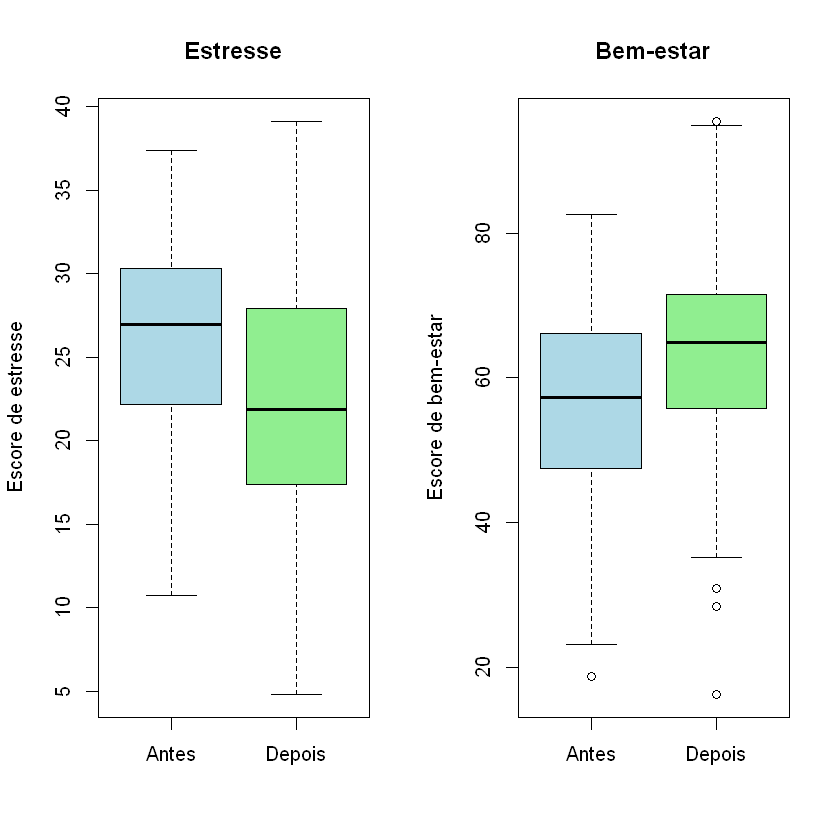

In [11]:
par(mfrow = c(1, 2))

boxplot(dados$estresse_antes_mindfulness, dados$estresse_depois_mindfulness,
        names = c("Antes", "Depois"),
        main = "Estresse",
        ylab = "Escore de estresse",
        col = c("lightblue", "lightgreen"))

boxplot(dados$bem_estar_antes_mindfulness, dados$bem_estar_depois_mindfulness,
        names = c("Antes", "Depois"),
        main = "Bem-estar",
        ylab = "Escore de bem-estar",
        col = c("lightblue", "lightgreen"))


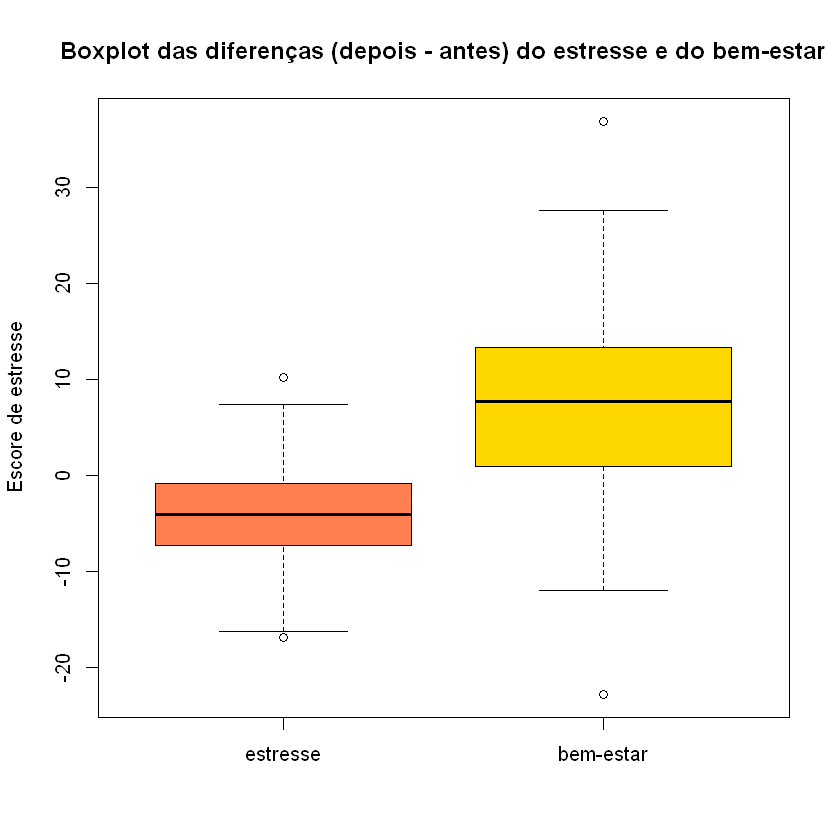

In [21]:
par(mfrow = c(1, 1))

boxplot(d$d_estresse, d$d_bem_estar,
        names = c("estresse", "bem-estar"),
        main = "Boxplot das diferenças (depois - antes) do estresse e do bem-estar",
        ylab = "Escore de estresse",
        col = c("coral", "gold"))

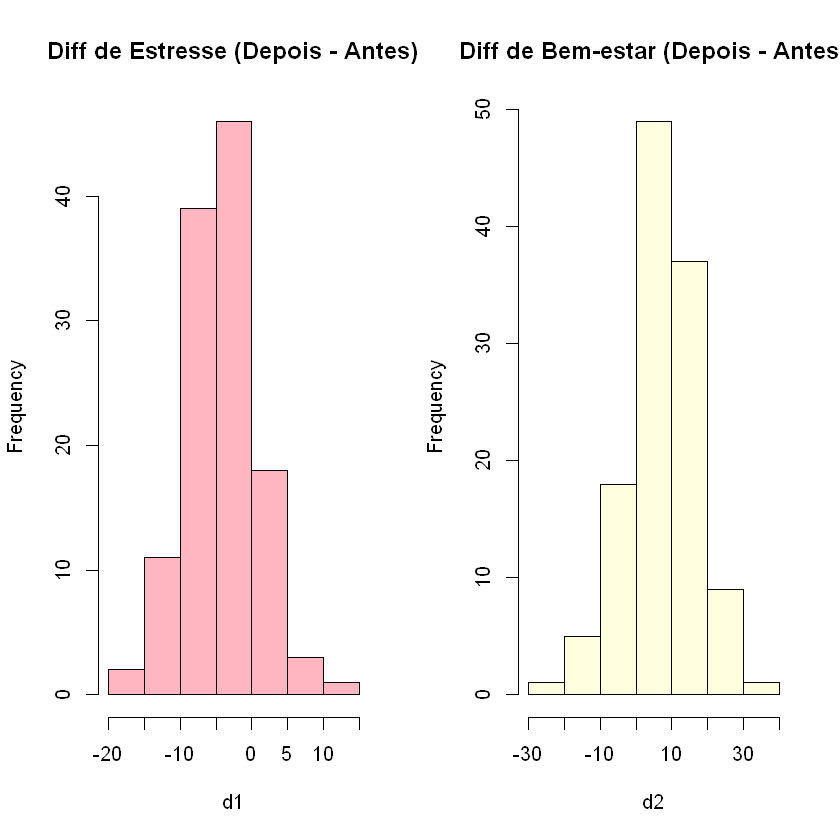

In [13]:
par(mfrow = c(1, 2))

hist(d$d_estresse,
     main = "Diff de Estresse (Depois - Antes)",
     xlab = "d1",
     col = "lightpink")

hist(d$d_bem_estar,
     main = "Diff de Bem-estar (Depois - Antes)",
     xlab = "d2",
     col = "lightyellow")


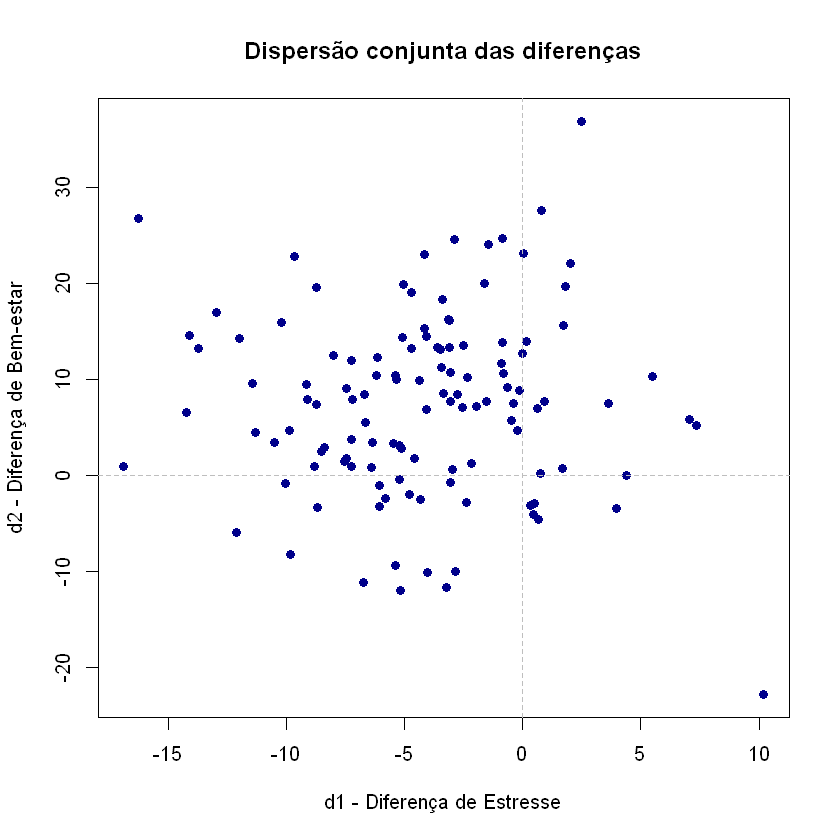

In [14]:
plot(d$d_estresse, d$d_bem_estar,
     main = "Dispersão conjunta das diferenças",
     xlab = "d1 - Diferença de Estresse",
     ylab = "d2 - Diferença de Bem-estar",
     pch = 19, col = "darkblue")
abline(h = 0, v = 0, lty = 2, col = "gray")


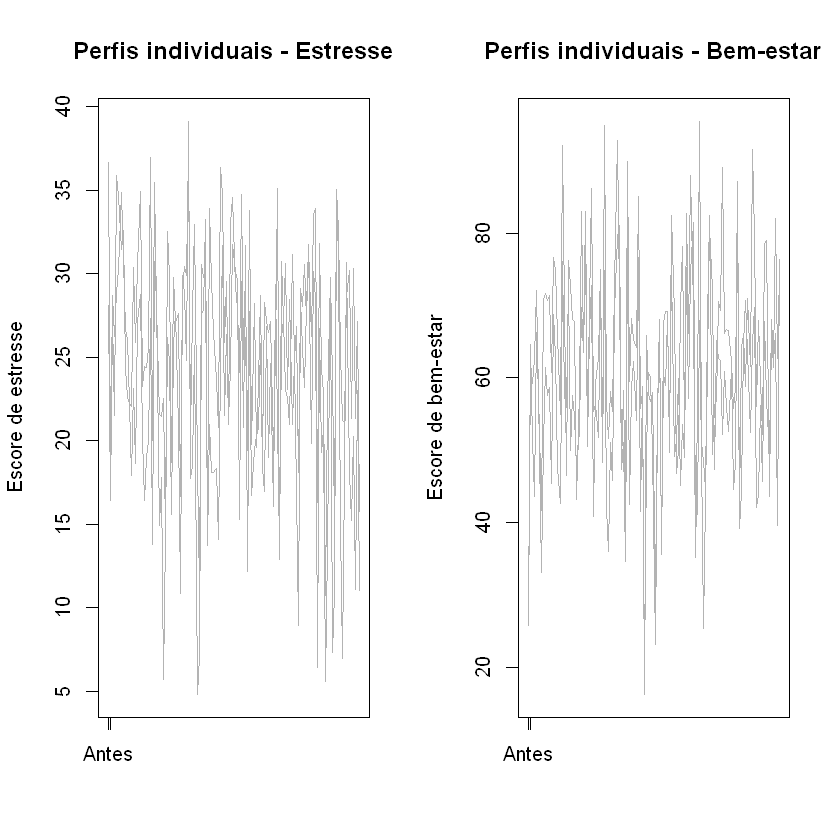

In [15]:
par(mfrow = c(1, 2))

matplot(t(rbind(dados$estresse_antes_mindfulness, dados$estresse_depois_mindfulness)),
        type = "l", lty = 1, col = "gray70",
        xaxt = "n", main = "Perfis individuais - Estresse",
        xlab = "", ylab = "Escore de estresse")
axis(1, at = c(1, 2), labels = c("Antes", "Depois"))

matplot(t(rbind(dados$bem_estar_antes_mindfulness, dados$bem_estar_depois_mindfulness)),
        type = "l", lty = 1, col = "gray70",
        xaxt = "n", main = "Perfis individuais - Bem-estar",
        xlab = "", ylab = "Escore de bem-estar")
axis(1, at = c(1, 2), labels = c("Antes", "Depois"))


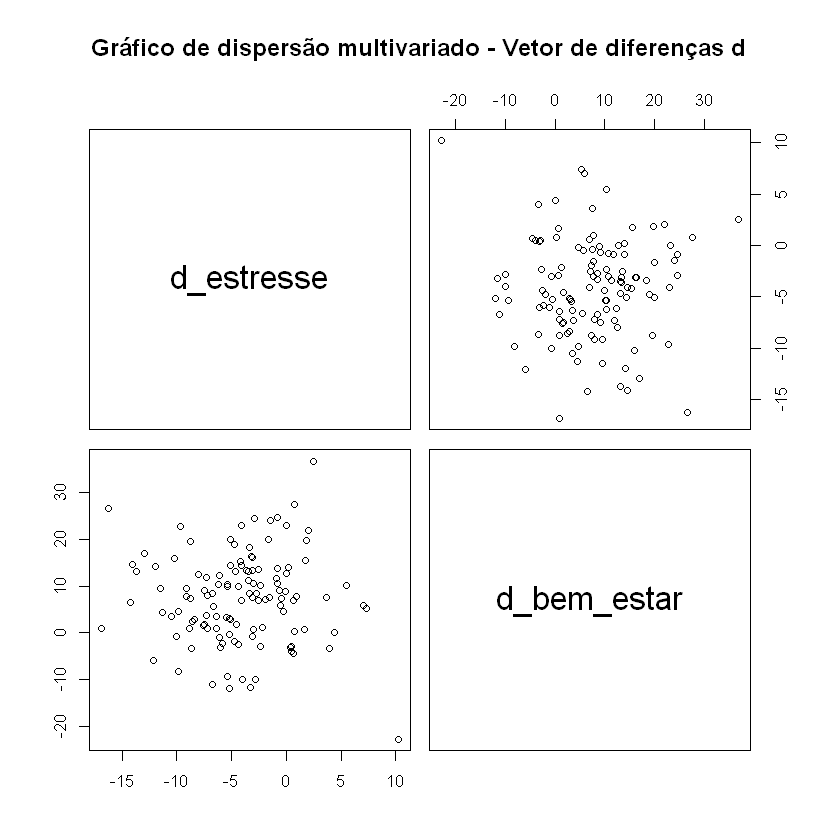

In [16]:
pairs(d, main = "Gráfico de dispersão multivariado - Vetor de diferenças d")
